In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline
import scipy.stats as stats
import plotly.express as px
from sklearn.metrics import accuracy_score

In [2]:
df  = pd.read_csv("data/Used_Bikes.csv")

In [3]:
df

,bike_name,price,city,kms_driven,owner,age,power,brand
0,TVS Star City Plus Dual Tone 110cc,35000.0,Ahmedabad,17654.0,First Owner,3.0,110.0,TVS
1,Royal Enfield Classic 350cc,119900.0,Delhi,11000.0,First Owner,4.0,350.0,Royal Enfield
2,Triumph Daytona 675R,600000.0,Delhi,110.0,First Owner,8.0,675.0,Triumph
3,TVS Apache RTR 180cc,65000.0,Bangalore,16329.0,First Owner,4.0,180.0,TVS
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000.0,Bangalore,10000.0,First Owner,3.0,150.0,Yamaha
...,...,...,...,...,...,...,...,...
32643,Hero Passion Pro 100cc,39000.0,Delhi,22000.0,First Owner,4.0,100.0,Hero
32644,TVS Apache RTR 180cc,30000.0,Karnal,6639.0,First Owner,9.0,180.0,TVS
32645,Bajaj Avenger Street 220,60000.0,Delhi,20373.0,First Owner,6.0,220.0,Bajaj
32646,Hero Super Splendor 125cc,15600.0,Jaipur,84186.0,First Owner,16.0,125.0,Hero


In [4]:
df['bike_name'] = df['bike_name'].str.replace(r'\s*\d+(\.\d+)?\s*cc\b', '', regex=True, case=False)
df['bike_name'] = df['bike_name'].str.strip()

In [5]:
df.duplicated().mean()*100

np.float64(77.56677284979172)

In [6]:
df[df.duplicated(keep=False)].sort_values(by='bike_name').sample(10)

,bike_name,price,city,kms_driven,owner,age,power,brand
27462,Suzuki Slingshot Plus,32000.0,Lucknow,22697.0,First Owner,7.0,125.0,Suzuki
19462,Yamaha FZ,45000.0,Chennai,18742.0,First Owner,6.0,150.0,Yamaha
22510,Bajaj Pulsar,25000.0,Delhi,32588.0,First Owner,9.0,150.0,Bajaj
12771,Harley-Davidson Street 750 ABS,450000.0,Jodhpur,3430.0,First Owner,4.0,750.0,Harley-Davidson
12023,Yamaha Fazer 25,123000.0,Kadapa,14500.0,First Owner,4.0,250.0,Yamaha
29305,Honda CB Trigger,43000.0,Bangalore,42837.0,First Owner,8.0,150.0,Honda
30657,Royal Enfield Bullet Electra,105000.0,Delhi,20000.0,First Owner,4.0,350.0,Royal Enfield
2773,Bajaj Pulsar,50000.0,Gangaikondan,20000.0,First Owner,6.0,180.0,Bajaj
24337,Hero Passion Pro,32000.0,Delhi,12000.0,First Owner,6.0,100.0,Hero
14687,Hero CD Deluxe,18000.0,Chennai,22824.0,First Owner,8.0,100.0,Hero


In [7]:
df = df.drop_duplicates()

In [8]:
df.shape

(7324, 8)

In [9]:
df.isnull().mean()*100

bike_name     0.0
price         0.0
city          0.0
kms_driven    0.0
owner         0.0
age           0.0
power         0.0
brand         0.0
dtype: float64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7324 entries, 0 to 9372
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bike_name   7324 non-null   object 
 1   price       7324 non-null   float64
 2   city        7324 non-null   object 
 3   kms_driven  7324 non-null   float64
 4   owner       7324 non-null   object 
 5   age         7324 non-null   float64
 6   power       7324 non-null   float64
 7   brand       7324 non-null   object 
dtypes: float64(4), object(4)
memory usage: 515.0+ KB


In [11]:
df['brand'].unique()

array(['TVS', 'Royal Enfield', 'Triumph', 'Yamaha', 'Honda', 'Hero',
       'Bajaj', 'Suzuki', 'Benelli', 'KTM', 'Mahindra', 'Kawasaki',
       'Ducati', 'Hyosung', 'Harley-Davidson', 'Jawa', 'BMW', 'Indian',
       'Rajdoot', 'LML', 'Yezdi', 'MV', 'Ideal'], dtype=object)

In [12]:
df.describe()

,price,kms_driven,age,power
count,7.324000e+03,7324.000000,7324.000000,7324.000000
mean,8.488390e+04,23910.496587,6.656472,228.133397
std,1.209662e+05,27317.594631,3.605299,158.324219
min,4.400000e+03,1.000000,1.000000,100.000000
25%,3.000000e+04,10155.750000,4.000000,125.000000
50%,5.500000e+04,19000.000000,6.000000,160.000000
75%,1.000000e+05,30112.000000,8.000000,350.000000
max,1.900000e+06,750000.000000,63.000000,1800.000000


In [13]:
#change data type of - price , kms_driven , age , power 
#remuve brand name to the bike name and also remove cc 


In [14]:
#change data type 
df['age'] = df['age'].astype('int')
df['power'] = df['power'].astype('int')
df['price'] = df['price'].astype('int')
df['kms_driven'] = df['kms_driven'].astype('int')

C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\853903108.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age'] = df['age'].astype('int')
C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\853903108.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['power'] = df['power'].astype('int')
C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\853903108.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instea

In [15]:
df['bike_name'] = df.apply(
    lambda row: row['bike_name'].replace(row['brand'], '', 1).strip(),
    axis=1
)

C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\84371063.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bike_name'] = df.apply(


In [16]:
df

,bike_name,price,city,kms_driven,owner,age,power,brand
0,Star City Plus Dual Tone,35000,Ahmedabad,17654,First Owner,3,110,TVS
1,Classic,119900,Delhi,11000,First Owner,4,350,Royal Enfield
2,Daytona 675R,600000,Delhi,110,First Owner,8,675,Triumph
3,Apache RTR,65000,Bangalore,16329,First Owner,4,180,TVS
4,FZ S V 2.0-Ltd. Edition,80000,Bangalore,10000,First Owner,3,150,Yamaha
...,...,...,...,...,...,...,...,...
9362,Hunk Rear Disc,25000,Delhi,48587,First Owner,8,150,Hero
9369,Avenger,35000,Bangalore,60000,First Owner,9,220,Bajaj
9370,Street 750 ABS,450000,Jodhpur,3430,First Owner,4,750,Harley-Davidson
9371,Dominar 400 ABS,139000,Hyderabad,21300,First Owner,4,400,Bajaj


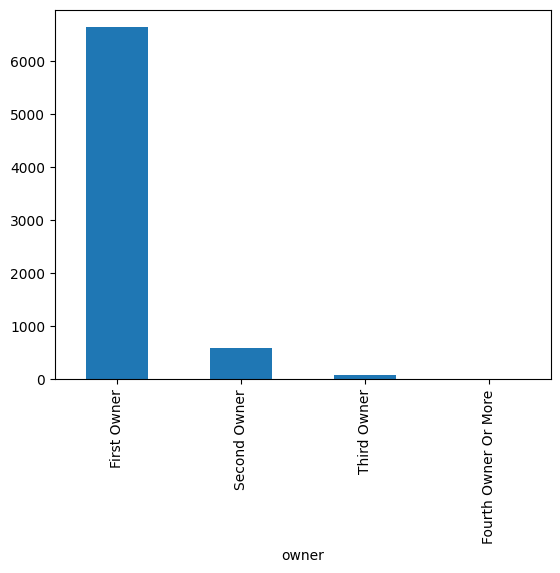

In [17]:
df['owner'].value_counts().plot(kind="bar")
plt.show()

Text(0.5, 1.0, 'brand count ')

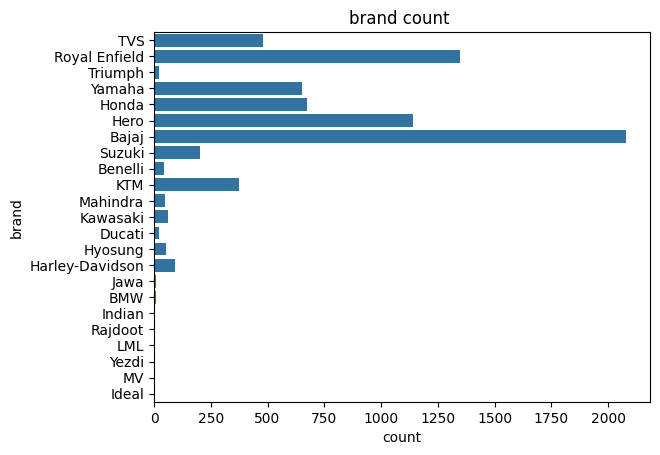

In [18]:
sns.countplot(df['brand'])
plt.title("brand count ")

<Axes: ylabel='age'>

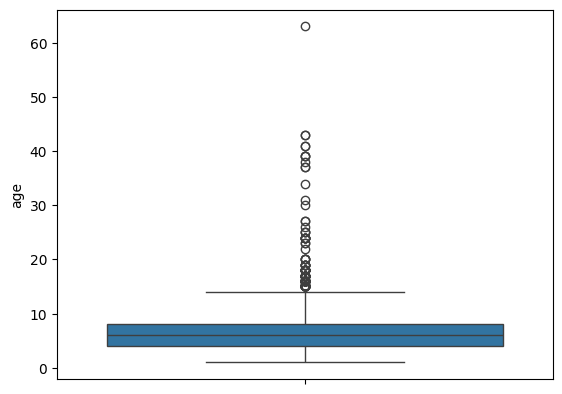

In [19]:
sns.boxplot(df['age'])

<Axes: ylabel='age'>

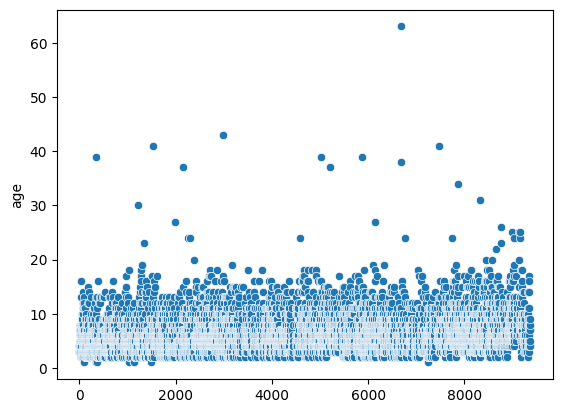

In [20]:
sns.scatterplot(df['age'])

<Axes: ylabel='power'>

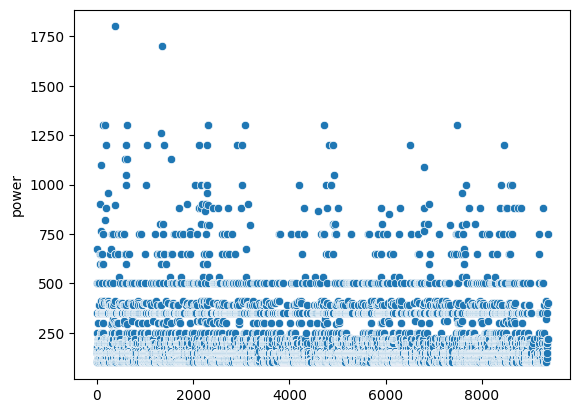

In [21]:
sns.scatterplot(df['power'])

In [22]:
df['city']

0       Ahmedabad
1           Delhi
2           Delhi
3       Bangalore
4       Bangalore
          ...    
9362        Delhi
9369    Bangalore
9370      Jodhpur
9371    Hyderabad
9372    Hyderabad
Name: city, Length: 7324, dtype: object

In [23]:
group1 = df.groupby(["city" , "brand"]).size()

In [24]:
group1['Aligarh']

brand
Bajaj     1
TVS       1
Yamaha    1
dtype: int64

In [25]:
group1['Agra']

brand
Bajaj    5
Hero     1
Honda    3
dtype: int64

Text(0, 0.5, 'number of bikes')

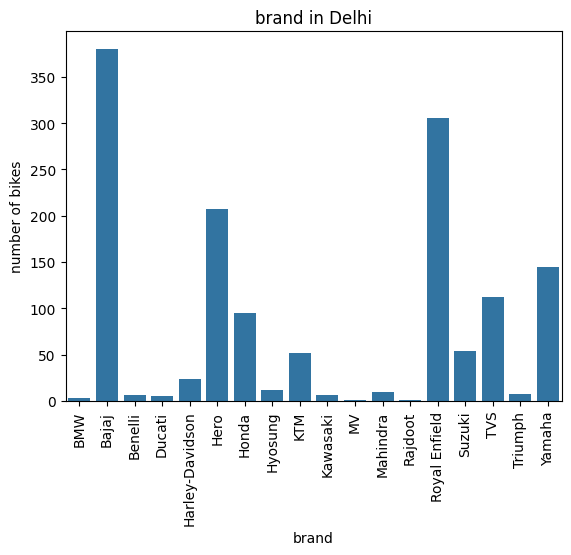

In [26]:
sns.barplot(group1['Delhi'])
plt.xticks(rotation =90)
plt.title("brand in Delhi")
plt.ylabel("number of bikes" )

Text(0, 0.5, 'number of bikes')

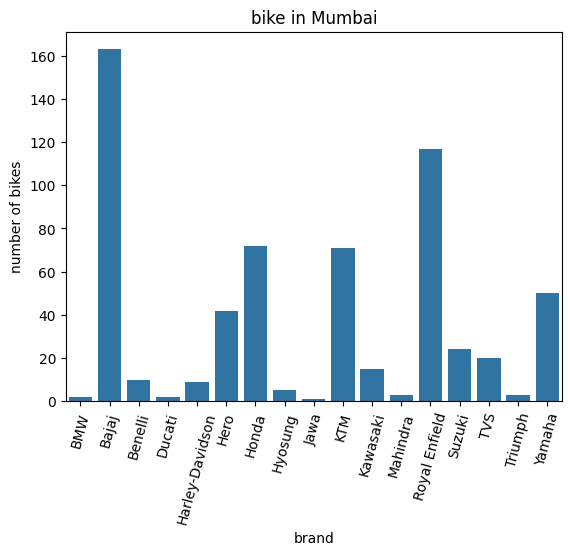

In [27]:
sns.barplot(group1['Mumbai'])
plt.title("bike in Mumbai")
plt.xticks(rotation = 75)
plt.ylabel("number of bikes")

In [28]:
df


,bike_name,price,city,kms_driven,owner,age,power,brand
0,Star City Plus Dual Tone,35000,Ahmedabad,17654,First Owner,3,110,TVS
1,Classic,119900,Delhi,11000,First Owner,4,350,Royal Enfield
2,Daytona 675R,600000,Delhi,110,First Owner,8,675,Triumph
3,Apache RTR,65000,Bangalore,16329,First Owner,4,180,TVS
4,FZ S V 2.0-Ltd. Edition,80000,Bangalore,10000,First Owner,3,150,Yamaha
...,...,...,...,...,...,...,...,...
9362,Hunk Rear Disc,25000,Delhi,48587,First Owner,8,150,Hero
9369,Avenger,35000,Bangalore,60000,First Owner,9,220,Bajaj
9370,Street 750 ABS,450000,Jodhpur,3430,First Owner,4,750,Harley-Davidson
9371,Dominar 400 ABS,139000,Hyderabad,21300,First Owner,4,400,Bajaj


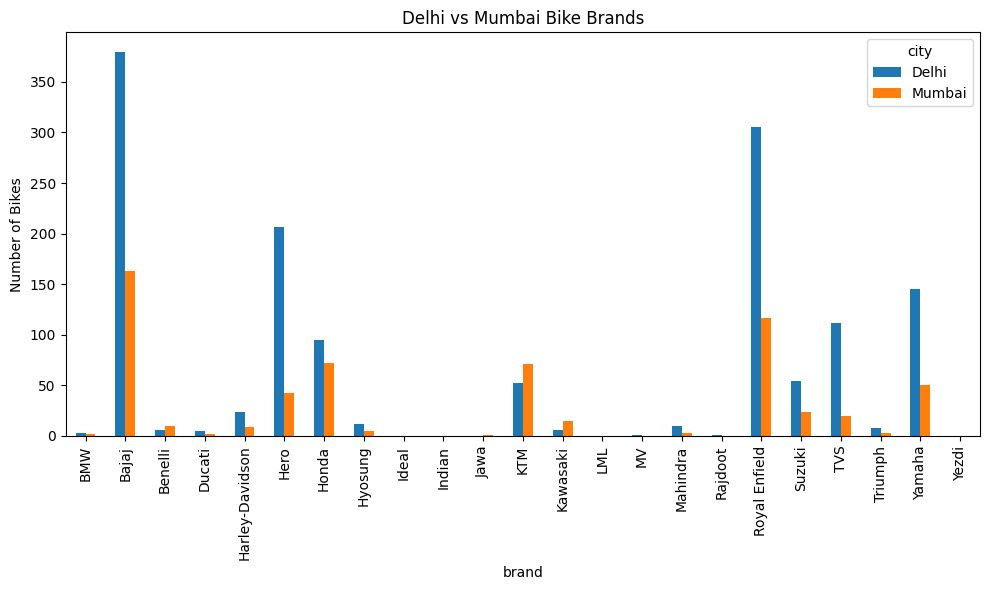

In [29]:
pd.crosstab(df['brand'], df['city'])[['Delhi', 'Mumbai']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.ylabel('Number of Bikes')
plt.title('Delhi vs Mumbai Bike Brands')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'bike price accourding to power ')

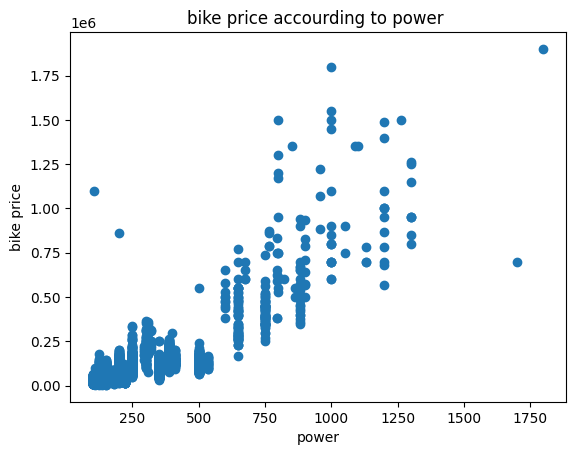

In [30]:

plt.scatter(df['power'], df['price'])
plt.xlabel("power")
plt.ylabel("bike price")
plt.title("bike price accourding to power ")

In [31]:
df.corr(numeric_only=True)

,price,kms_driven,age,power
price,1.000000,-0.199951,-0.248752,0.807641
kms_driven,-0.199951,1.000000,0.367518,-0.168295
age,-0.248752,0.367518,1.000000,-0.164211
power,0.807641,-0.168295,-0.164211,1.000000


Text(0.5, 1.0, 'age on QQ plot')

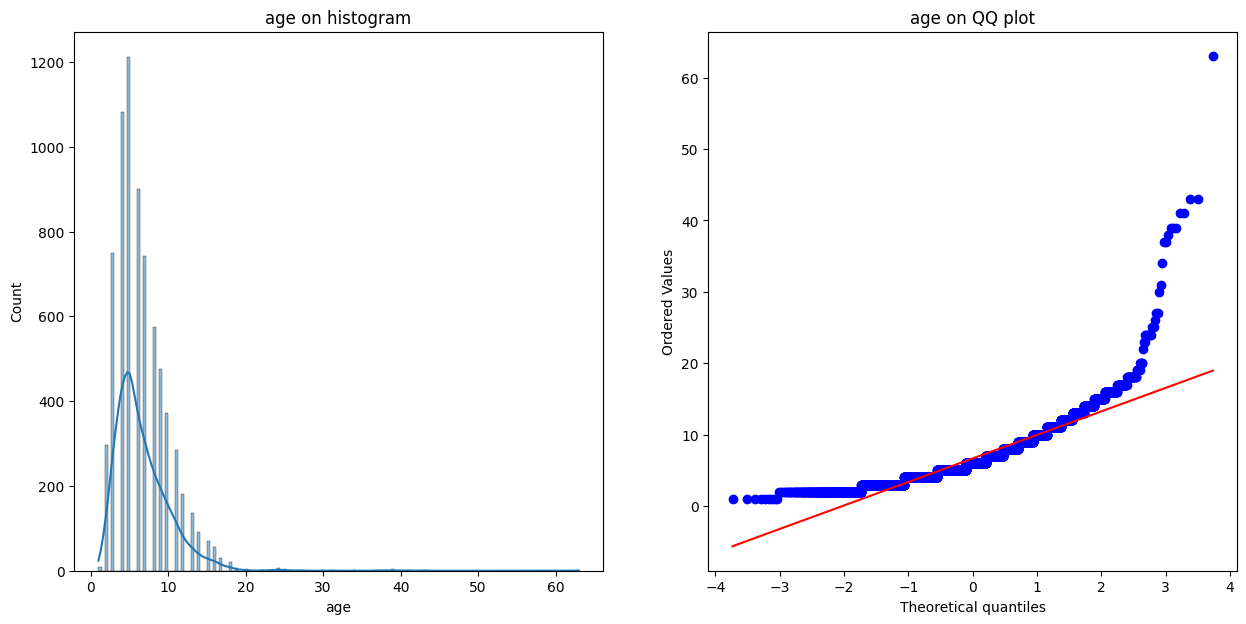

In [32]:
plt.figure(figsize=(15,7))
plt.subplot(121)
sns.histplot(df["age"] , kde=True)
plt.title("age on histogram")

plt.subplot(122)
stats.probplot(df["age"]  , plot=plt)
plt.title("age on QQ plot" )

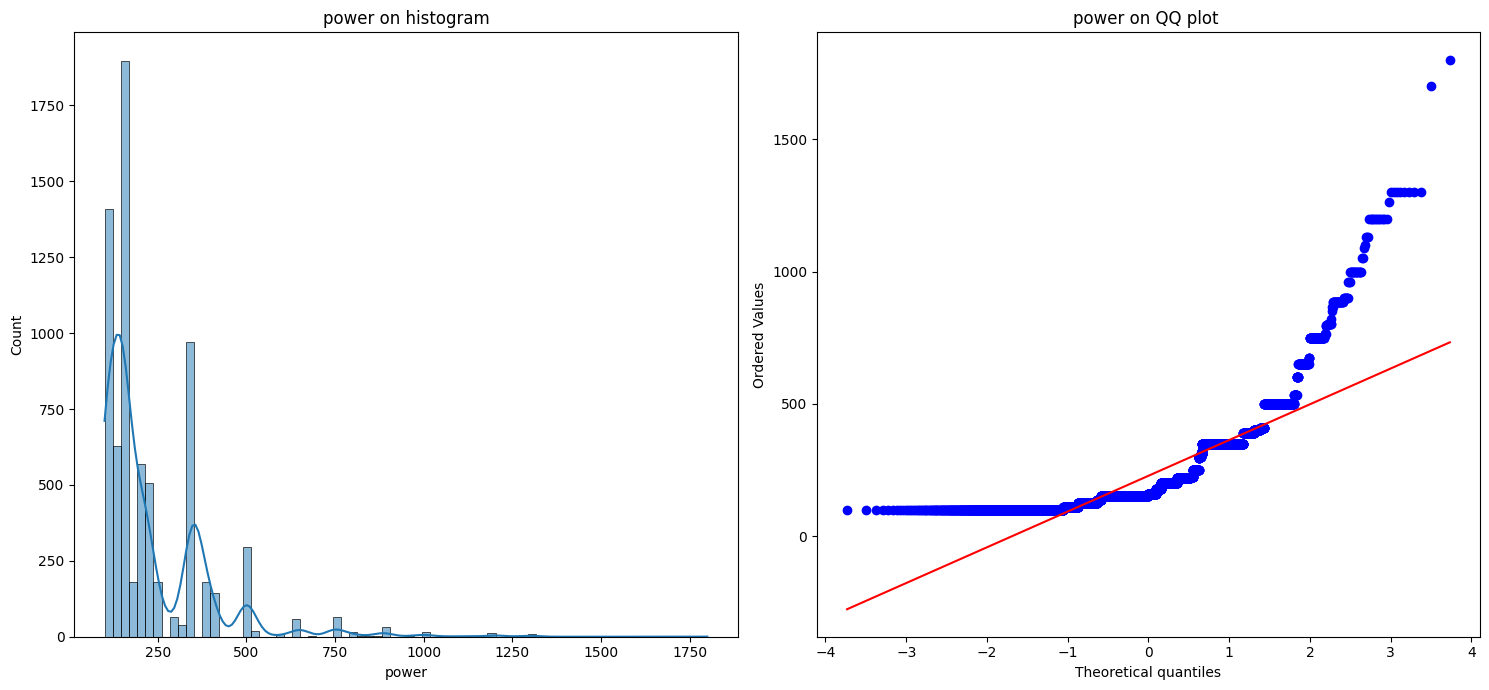

In [33]:
plt.figure(figsize=(15,7))
plt.subplot(121)
sns.histplot(df['power'] , kde=True)
plt.title("power on histogram")

plt.subplot(122)
stats.probplot(df['power'] , plot=plt)
plt.title('power on QQ plot ')
plt.tight_layout()

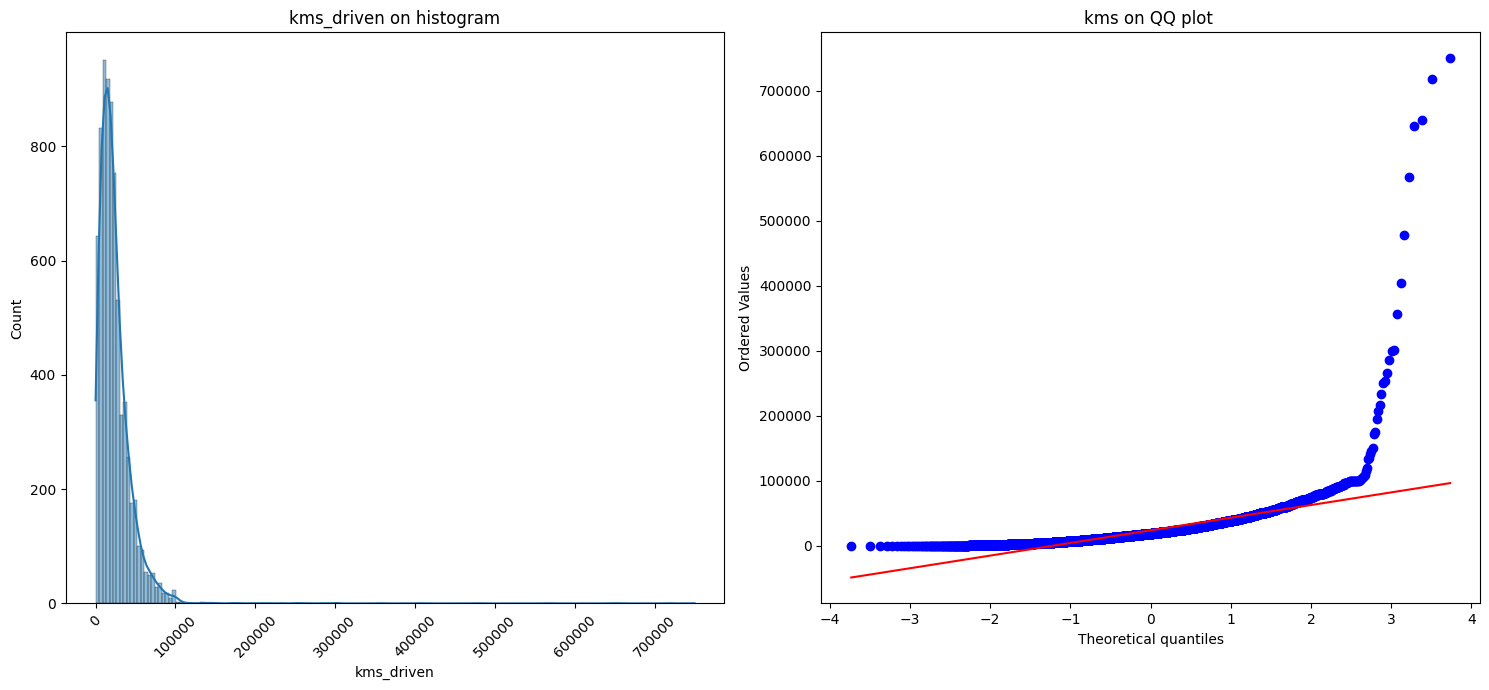

In [34]:
plt.figure(figsize=(15,7))
plt.subplot(121)
sns.histplot(df['kms_driven'] , kde = True)
plt.xticks(rotation = 45)
plt.title("kms_driven on histogram")

plt.subplot(122)
stats.probplot(df['kms_driven'] , plot=plt)
plt.title('kms on QQ plot ')

plt.tight_layout()


In [35]:
df.skew(numeric_only=True)

price          6.266096
kms_driven    11.705304
age            2.628402
power          2.615521
dtype: float64

In [36]:
df

,bike_name,price,city,kms_driven,owner,age,power,brand
0,Star City Plus Dual Tone,35000,Ahmedabad,17654,First Owner,3,110,TVS
1,Classic,119900,Delhi,11000,First Owner,4,350,Royal Enfield
2,Daytona 675R,600000,Delhi,110,First Owner,8,675,Triumph
3,Apache RTR,65000,Bangalore,16329,First Owner,4,180,TVS
4,FZ S V 2.0-Ltd. Edition,80000,Bangalore,10000,First Owner,3,150,Yamaha
...,...,...,...,...,...,...,...,...
9362,Hunk Rear Disc,25000,Delhi,48587,First Owner,8,150,Hero
9369,Avenger,35000,Bangalore,60000,First Owner,9,220,Bajaj
9370,Street 750 ABS,450000,Jodhpur,3430,First Owner,4,750,Harley-Davidson
9371,Dominar 400 ABS,139000,Hyderabad,21300,First Owner,4,400,Bajaj


In [37]:
df['age'].unique()

array([ 3,  4,  8,  6,  7,  5,  2, 16, 13,  9, 10, 14, 12, 11,  1, 15, 39,
       17, 18, 30, 19, 23, 41, 27, 37, 24, 20, 43, 38, 63, 34, 31, 22, 26,
       25])

In [38]:
df

,bike_name,price,city,kms_driven,owner,age,power,brand
0,Star City Plus Dual Tone,35000,Ahmedabad,17654,First Owner,3,110,TVS
1,Classic,119900,Delhi,11000,First Owner,4,350,Royal Enfield
2,Daytona 675R,600000,Delhi,110,First Owner,8,675,Triumph
3,Apache RTR,65000,Bangalore,16329,First Owner,4,180,TVS
4,FZ S V 2.0-Ltd. Edition,80000,Bangalore,10000,First Owner,3,150,Yamaha
...,...,...,...,...,...,...,...,...
9362,Hunk Rear Disc,25000,Delhi,48587,First Owner,8,150,Hero
9369,Avenger,35000,Bangalore,60000,First Owner,9,220,Bajaj
9370,Street 750 ABS,450000,Jodhpur,3430,First Owner,4,750,Harley-Davidson
9371,Dominar 400 ABS,139000,Hyderabad,21300,First Owner,4,400,Bajaj


In [39]:
df.isnull().mean()*100

bike_name     0.0
price         0.0
city          0.0
kms_driven    0.0
owner         0.0
age           0.0
power         0.0
brand         0.0
dtype: float64

C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\3902189380.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'] )
C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\3902189380.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['power'])


Text(0.5, 1.0, 'dist plot of power')

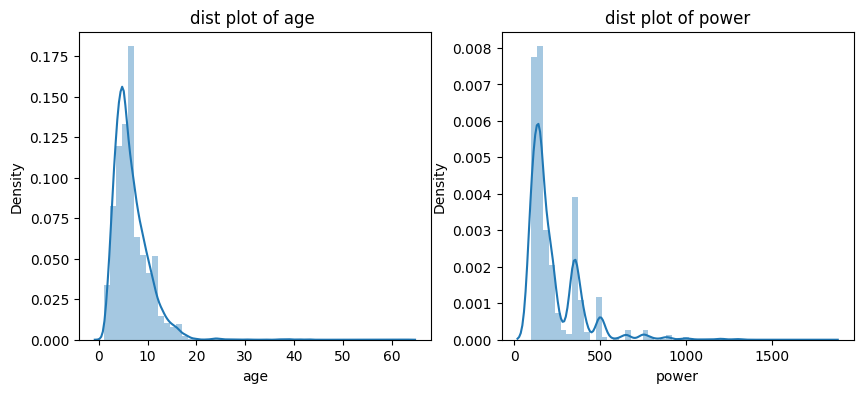

In [40]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.distplot(df['age'] )
plt.title("dist plot of age ")

plt.subplot(1,2,2)
sns.distplot(df['power'])
plt.title("dist plot of power")

<Axes: xlabel='power'>

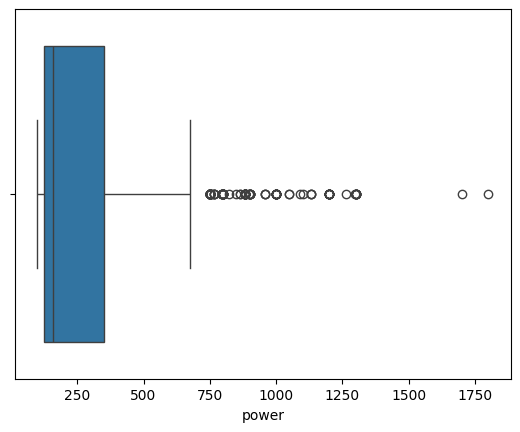

In [41]:
sns.boxplot(x = df['power'])

<Axes: xlabel='age'>

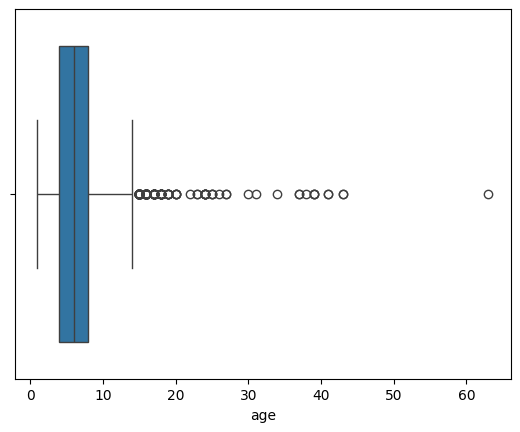

In [42]:
sns.boxplot(x = df['age'])

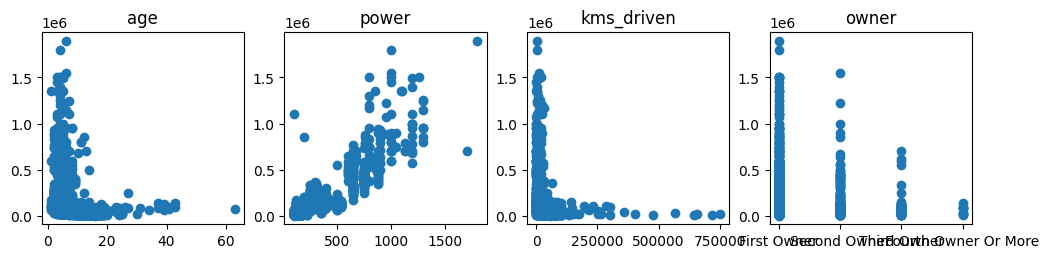

In [43]:
fig, (ax1, ax2, ax3 , ax4) = plt.subplots(ncols=4, figsize=(12, 2.5))

ax1.scatter(df['age'], df['price'])
ax1.set_title("age")

ax2.scatter(df['power'], df['price'])
ax2.set_title("power")

ax3.scatter(df['kms_driven'], df['price'])
ax3.set_title("kms_driven")

ax4.scatter(df['owner'], df['price'])
ax4.set_title("owner")

plt.show()

In [44]:
#finding the iqr 
percentage25 = df['age'].quantile(0.25)
percentage75 = df['age'].quantile(0.75)

In [45]:
IQR = percentage75 - percentage25

In [46]:
IQR

np.float64(4.0)

In [47]:
upper_limit = percentage75 + 1.5*IQR
lower_limit = percentage25 - 1.5*IQR

In [48]:
print("upper limit" , upper_limit)
print("lower limit " , lower_limit)

upper limit 14.0
lower limit  -2.0


In [49]:
df[df['age']>upper_limit]

,bike_name,price,city,kms_driven,owner,age,power,brand
26,Super Splendor,20000,Ahmedabad,29305,First Owner,16,125,Hero
177,Karizma,15000,Delhi,38000,First Owner,15,223,Hero
334,Bullet,125000,Hyderabad,16500,First Owner,39,350,Royal Enfield
385,Thunderbird,46000,Chennai,35000,First Owner,16,350,Royal Enfield
698,Passion,21100,Visakhapatnam,30000,First Owner,16,100,Hero
...,...,...,...,...,...,...,...,...
9193,Passion Plus,16000,Hyderabad,23105,First Owner,15,100,Hero
9194,Ambition,5000,Delhi,82178,First Owner,18,135,Hero
9201,Pulsar,15000,Gurgaon,70000,First Owner,16,150,Bajaj
9339,Splendor Plus,11400,Gurgaon,20000,Second Owner,17,100,Hero


In [50]:
df.shape

(7324, 8)

In [51]:
#capping the outliers


In [52]:
new_df_cap = df.copy()
new_df_cap['age'] = np.where(
    new_df_cap['age']> upper_limit, 
    upper_limit,
    np.where(
        new_df_cap['age']<lower_limit,
        lower_limit, 
        new_df_cap['age']
    )
)

In [53]:
bikes = new_df_cap.copy()

<Axes: xlabel='age'>

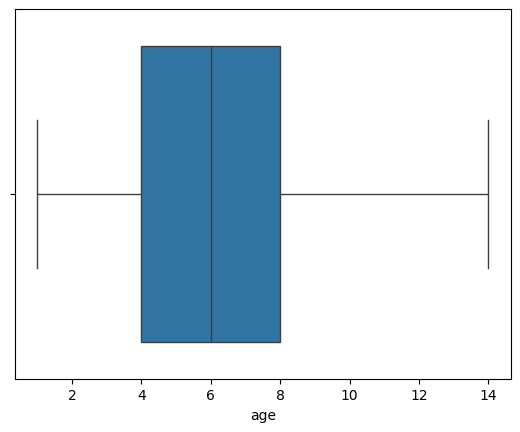

In [54]:
sns.boxplot(x = new_df_cap['age'])

C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\540409872.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'] )
C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\540409872.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['age'])


Text(0.5, 1.0, 'after capping outliers')

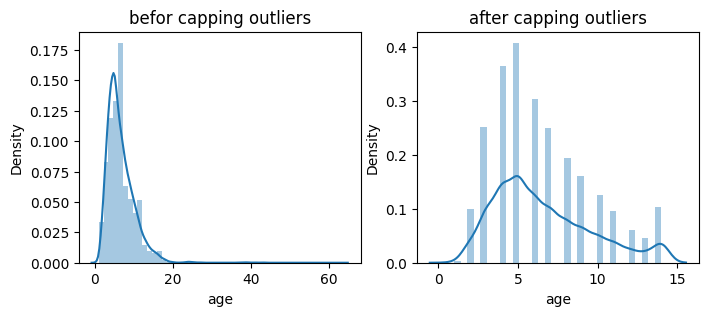

In [55]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
sns.distplot(df['age'] )
plt.title("befor capping outliers")

plt.subplot(1,2,2)
sns.distplot(new_df_cap['age'])
plt.title("after capping outliers")

<Axes: xlabel='power'>

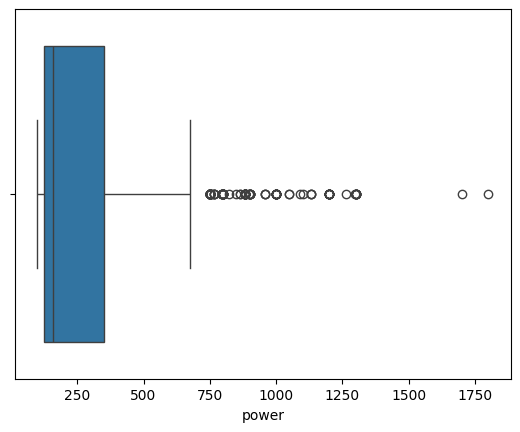

In [56]:
sns.boxplot(x =new_df_cap['power'])
#here power outliers is not outliers it is valid values so i not remove that 

In [57]:
df[df['brand'] == 'BMW']

,bike_name,price,city,kms_driven,owner,age,power,brand
359,G 310 R,255000,Mohali,2200,First Owner,3,310,BMW
567,G 310 R,260000,Mumbai,8500,First Owner,3,310,BMW
1157,G 310 R,270000,Pune,12872,First Owner,2,310,BMW
2612,G 310 GS,350000,Mumbai,14482,First Owner,2,310,BMW
2956,G 310 R,360000,Bangalore,7093,First Owner,3,310,BMW
3016,S 1000 XR Pro,1500000,Delhi,18000,First Owner,4,1000,BMW
4864,S 1000 RR Pro,1800000,Delhi,2600,First Owner,4,1000,BMW
6070,F750 GS,1350000,Delhi,4600,First Owner,3,850,BMW
7597,G 310 R,260000,Bangalore,11000,First Owner,3,310,BMW
8510,G 310 GS,330000,Gurgaon,4241,First Owner,3,310,BMW


In [58]:
df['brand'].unique()

array(['TVS', 'Royal Enfield', 'Triumph', 'Yamaha', 'Honda', 'Hero',
       'Bajaj', 'Suzuki', 'Benelli', 'KTM', 'Mahindra', 'Kawasaki',
       'Ducati', 'Hyosung', 'Harley-Davidson', 'Jawa', 'BMW', 'Indian',
       'Rajdoot', 'LML', 'Yezdi', 'MV', 'Ideal'], dtype=object)

In [59]:
new_df_cap[new_df_cap['power'] > 1000].head()

,bike_name,price,city,kms_driven,owner,age,power,brand
92,Scrambler 1100 Special,1350000,Mumbai,190,First Owner,1.0,1100,Ducati
124,1299 Superleggera,800000,Mumbai,3,First Owner,3.0,1299,Ducati
167,Hayabusa,950000,Chennai,312,First Owner,3.0,1300,Suzuki
182,1198 SP,700000,Ahmedabad,100,First Owner,6.0,1198,Ducati
367,Chief Classic,1900000,Chennai,1700,First Owner,6.0,1800,Indian


C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\747076366.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['kms_driven'])


<Axes: xlabel='kms_driven'>

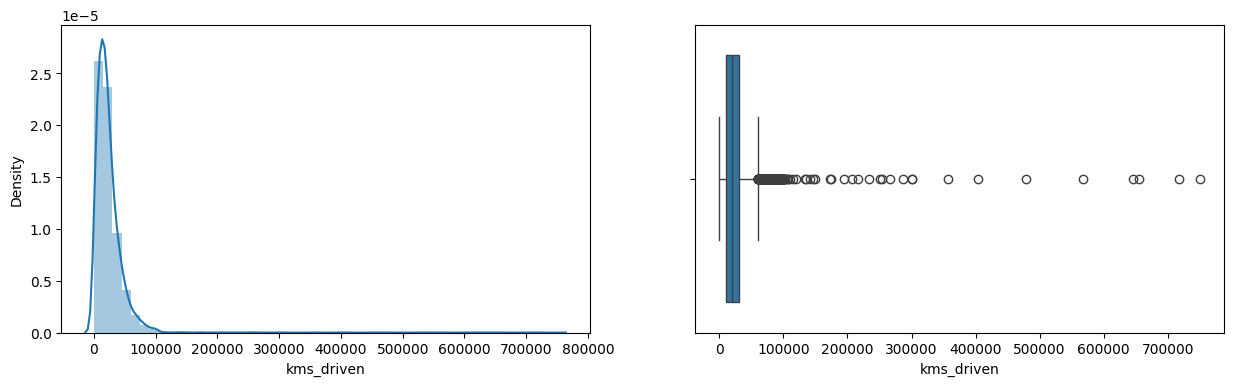

In [60]:
plt.figure(figsize=(15,4))
plt.subplot(121)
sns.distplot(new_df_cap['kms_driven'])

plt.subplot(122)
sns.boxplot(x = new_df_cap['kms_driven'])

In [61]:
df['power'].skew()

np.float64(2.6155206486463345)

In [62]:
from sklearn.preprocessing import PowerTransformer 
from sklearn.preprocessing import FunctionTransformer

In [63]:
pt = PowerTransformer(method="yeo-johnson")
new_df_cap['power_transformer'] = pt.fit_transform(new_df_cap[['power']])

In [64]:
trf = FunctionTransformer(func=np.log1p)

In [65]:
new_df_cap['log_power_transformer'] = trf.fit_transform(new_df_cap[['power']])

<Axes: xlabel='power_transformer'>

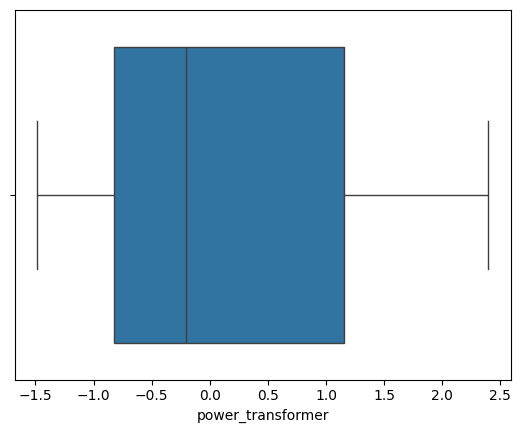

In [66]:
sns.boxplot(x = new_df_cap['power_transformer'])

<Axes: xlabel='log_power_transformer'>

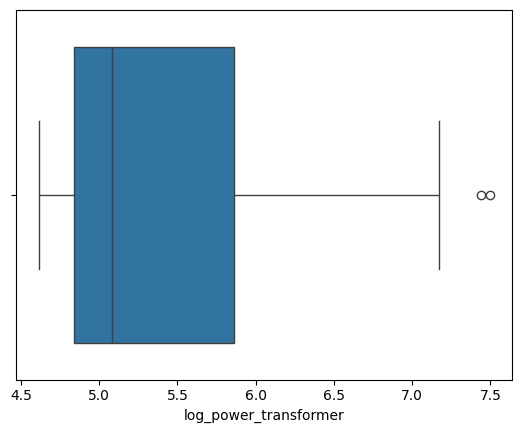

In [67]:
sns.boxplot( x = new_df_cap['log_power_transformer'])

C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\1980929309.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['power_transformer'])
C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\1980929309.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x = new_df_cap['log_power_transformer

Text(0.5, 1.0, 'log power transformer ')

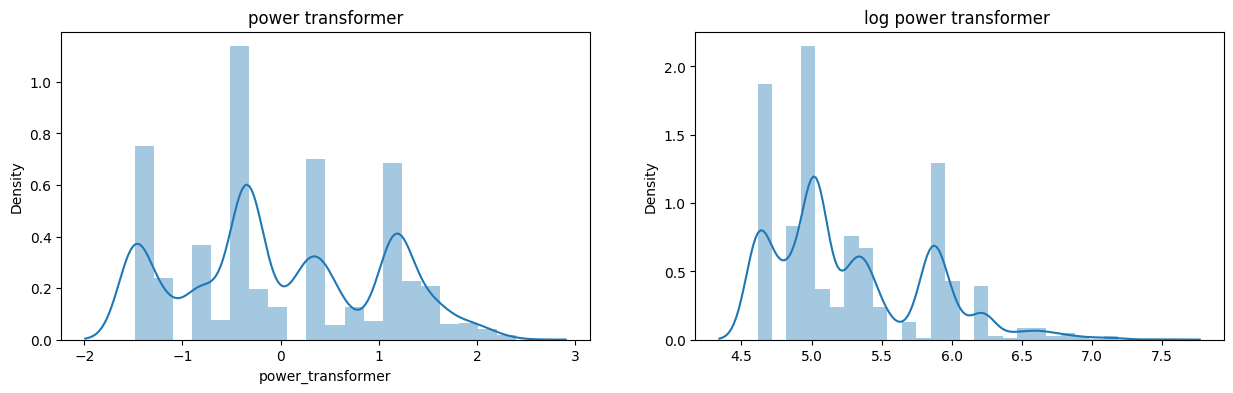

In [68]:
plt.figure(figsize=(15,4))
plt.subplot(121)
sns.distplot(new_df_cap['power_transformer'])
plt.title('power transformer')

plt.subplot(122)
sns.distplot(x = new_df_cap['log_power_transformer'])
plt.title('log power transformer ')
# sns.distplot(new_df_cap['power_transformer'])
# plt.figure(figsize=(10 , 4))

In [69]:
bikes

,bike_name,price,city,kms_driven,owner,age,power,brand
0,Star City Plus Dual Tone,35000,Ahmedabad,17654,First Owner,3.0,110,TVS
1,Classic,119900,Delhi,11000,First Owner,4.0,350,Royal Enfield
2,Daytona 675R,600000,Delhi,110,First Owner,8.0,675,Triumph
3,Apache RTR,65000,Bangalore,16329,First Owner,4.0,180,TVS
4,FZ S V 2.0-Ltd. Edition,80000,Bangalore,10000,First Owner,3.0,150,Yamaha
...,...,...,...,...,...,...,...,...
9362,Hunk Rear Disc,25000,Delhi,48587,First Owner,8.0,150,Hero
9369,Avenger,35000,Bangalore,60000,First Owner,9.0,220,Bajaj
9370,Street 750 ABS,450000,Jodhpur,3430,First Owner,4.0,750,Harley-Davidson
9371,Dominar 400 ABS,139000,Hyderabad,21300,First Owner,4.0,400,Bajaj


In [70]:
new_df_cap.head()

,bike_name,price,city,kms_driven,owner,age,power,brand,power_transformer,log_power_transformer
0,Star City Plus Dual Tone,35000,Ahmedabad,17654,First Owner,3.0,110,TVS,-1.188718,4.709530
1,Classic,119900,Delhi,11000,First Owner,4.0,350,Royal Enfield,1.157693,5.860786
2,Daytona 675R,600000,Delhi,110,First Owner,8.0,675,Triumph,1.834199,6.516193
3,Apache RTR,65000,Bangalore,16329,First Owner,4.0,180,TVS,0.050748,5.198497
4,FZ S V 2.0-Ltd. Edition,80000,Bangalore,10000,First Owner,3.0,150,Yamaha,-0.357849,5.017280


In [71]:
new_df_cap['power_transformer'].skew()

np.float64(0.14132100691450966)

In [72]:
new_df_cap['log_power_transformer'].skew()

np.float64(0.798495204913812)

In [73]:
 new_df_cap = new_df_cap.drop(columns=['log_power_transformer' , 'power_transformer' ])

In [74]:
new_df_cap.shape

(7324, 8)

C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\3021422379.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((new_df_cap['price']))


<Axes: xlabel='price', ylabel='Density'>

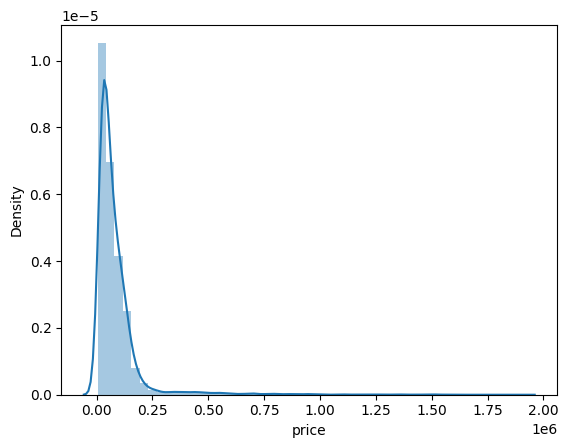

In [127]:
sns.distplot((new_df_cap['price']))

In [75]:
df.to_csv('models/bike_data.csv', index=False)

In [76]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [77]:
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import CountEncoder

In [78]:
x = new_df_cap.drop('price',axis = 1)
y = new_df_cap['price']

In [79]:
x_train , x_test , y_train , y_test = train_test_split(
    x ,
    y ,
    random_state=42,
    test_size=0.2
)

In [80]:
# # Step 1: Sirf training data se frequency map banayein (leakage avoid karne ke liye)
# freq_map = x_train['bike_name'].value_counts().to_dict()

# # Step 2: Train aur test dono pe apply karein using train ka map
# x_train['bike_name_freq'] = x_train['bike_name'].map(freq_map)
# x_test['bike_name_freq'] = x_test['bike_name'].map(freq_map)

# # Step 3: Test mein agar koi bike_name hai jo train mein nahi tha, to NaN aayega -> 0 se fill karein
# x_test['bike_name_freq'] = x_test['bike_name_freq'].fillna(0)

# # Step 4: Original bike_name column drop kar dein (ab OneHotEncoder mein isse include mat karein)
# x_train = x_train.drop(columns=['bike_name'])
# x_test = x_test.drop(columns=['bike_name'])

In [81]:
x_train

,bike_name,city,kms_driven,owner,age,power,brand
5789,Victor GX,Mumbai,68857,First Owner,14.0,110,TVS
3451,Thunderbird,Pune,5740,First Owner,6.0,500,Royal Enfield
735,Passion Xpro,Hoshiarpur,28329,First Owner,6.0,110,Hero
7533,FZ S V 2.0,Bangalore,42966,First Owner,7.0,150,Yamaha
8461,Classic Squadron Blue,Jaipur,8000,First Owner,5.0,500,Royal Enfield
...,...,...,...,...,...,...,...
6522,Pulsar NS200,Kolkata,56000,First Owner,9.0,200,Bajaj
6583,Thunderbird,Hyderabad,22493,First Owner,5.0,500,Royal Enfield
6856,Avenger Street 150,Faridabad,17477,First Owner,5.0,150,Bajaj
1028,FZ16,Mumbai,14836,First Owner,8.0,150,Yamaha


In [82]:
y_train

5789     18000
3451    140000
735      32000
7533     40000
8461    160000
         ...  
6522     48928
6583    114000
6856     41000
1028     40000
9250     80000
Name: price, Length: 5859, dtype: int64

In [83]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5859 entries, 5789 to 9250
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bike_name   5859 non-null   object 
 1   city        5859 non-null   object 
 2   kms_driven  5859 non-null   int64  
 3   owner       5859 non-null   object 
 4   age         5859 non-null   float64
 5   power       5859 non-null   int64  
 6   brand       5859 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 366.2+ KB


In [84]:
x_train['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth Owner Or More'], dtype=object)

In [85]:

preprocessor = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown="ignore" , sparse_output=False), ["city", "brand"]),
    ("freq", CountEncoder(normalize=True, handle_unknown=0, handle_missing=0), ["bike_name"]),
    ("ordinal", OrdinalEncoder(
        categories=[[
            "First Owner",
            "Second Owner",
            "Third Owner",
            "Fourth Owner Or More"
        ]]
    ), ["owner"]),
    
    ("scale", StandardScaler(), ["age", "kms_driven"]),
    
    ("power", PowerTransformer(), ["power"])
],remainder='passthrough')



In [86]:
from sklearn import set_config

set_config(display="diagram")

preprocessor

,transformers,"[('onehot', ...), ('freq', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,False


In [87]:
x_train_transformed= preprocessor.fit_transform(x_train)
x_test_transformed = preprocessor.transform(x_test)

In [88]:
x_train_transformed.shape

(5859, 423)

## now train thew model 

In [89]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score

In [90]:
# lr = LinearRegression()
# lr.fit(x_train_transformed , y_train)

In [91]:
# lr_rmses = -cross_val_score(
#     lr , 
#     x_train_transformed,
#     y_train,
#     scoring = "neg_root_mean_squared_error", 
#     cv= 10 
# )

In [92]:
# print("linear  regression cv RMSEs " , lr_rmses)

In [93]:
# print (pd.Series(lr_rmses).describe())

In [94]:
# y_pred = lr.predict(x_test_transformed)

In [95]:
# r2 = r2_score(y_test, y_pred)
# print("R² Score:", r2)

In [96]:
#random forrest rergresor
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(x_train_transformed , y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [97]:
forest_rmses = -cross_val_score(
    forest_reg , 
    x_train_transformed,
    y_train,
    scoring = "neg_root_mean_squared_error", 
    cv= 10 
)

In [98]:
 print("forest regression cv RMSEs " , forest_rmses)

forest regression cv RMSEs  [31191.32509941 25740.87513796 21531.66519588 32672.39127515
 55062.39266792 24245.49362798 40422.50928546 48591.30574444
 28165.04361584 27083.88837696]


In [99]:
print (pd.Series(forest_rmses).describe())

count       10.000000
mean     33470.689003
std      11082.172565
min      21531.665196
25%      26076.628448
50%      29678.184358
75%      38484.979783
max      55062.392668
dtype: float64


In [100]:
y_pred = forest_reg.predict(x_test_transformed)

In [101]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.8845413541974717


In [102]:
#hyperparameter tuning in random forest regeration
rf = RandomForestRegressor(max_samples=0.75 , random_state=42)
rf.fit(x_train_transformed , y_train)
y_predict = rf.predict(x_test_transformed)
r2 = r2_score(y_test, y_predict)
print("R² Score:", r2)

R² Score: 0.8888300470402956


In [103]:
# DecisionTreeRegressor
# tree_reg = DecisionTreeRegressor(random_state=42)
# tree_reg.fit(x_train_transformed , y_train)

In [104]:
# tree_rmses = -cross_val_score(
#     tree_reg , 
#     x_train_transformed,
#     y_train,
#     scoring = "neg_root_mean_squared_error", 
#     cv= 10 
# )

In [105]:
# print("tree regression cv RMSEs " , tree_rmses)

In [106]:
# print (pd.Series(tree_rmses).describe())

In [107]:
# y_pred = tree_reg.predict(x_test_transformed)

In [108]:
# r2 = r2_score(y_test , y_pred)
# print("r2 score:",r2)

In [109]:
#ExtraTreesRegressor
# extra_reg = ExtraTreesRegressor(random_state=42)
# extra_reg.fit(x_train_transformed , y_train)

In [110]:
# extra_rmses = -cross_val_score(
#     extra_reg , 
#     x_train_transformed,
#     y_train,
#     scoring = "neg_root_mean_squared_error", 
#     cv= 10 
# )

In [111]:
# print("Extra Trees regression cv RMSEs " , extra_rmses)

In [112]:
# print (pd.Series(extra_rmses).describe())

In [113]:
# y_pred = extra_reg.predict(x_test_transformed)

In [114]:
# r2 = r2_score(y_test , y_pred)
# print("r2 score:" ,r2)

In [115]:
# from sklearn.linear_model import (
#     LinearRegression,
#     Ridge,
#     Lasso,
#     ElasticNet
# )

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor
)

# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.svm import SVR

In [116]:
models = {
   # "Ridge": Ridge(),
   # "Lasso": Lasso(),
   # "ElasticNet": ElasticNet(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
   # "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
    #"AdaBoost": AdaBoostRegressor(random_state=42),
   # "KNN": KNeighborsRegressor(),
   # "SVR": SVR()
}

In [117]:
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

results = {}

for name, model in models.items():

    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # RMSE - Cross Validation
    rmses = -cross_val_score(
        model_pipeline,
        x_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=10
    )

    # Fit model on complete training data
    model_pipeline.fit(x_train, y_train)

    # Prediction on test data
    y_pred = model_pipeline.predict(x_test)

    # R² - Normal Test Score
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "RMSE": rmses.mean(),
        "std":rmses.std(),
        "R²": r2
    }

    print(f"{name}")
    print(f"Mean RMSE : {rmses.mean():,.2f}")
    print(f"Std RMSE  : {rmses.std():,.2f}")
    print(f"R² Score  : {r2:.4f}")
    print("-" * 40)

Gradient Boosting
Mean RMSE : 35,098.62
Std RMSE  : 9,828.75
R² Score  : 0.8856
----------------------------------------


In [118]:
Gradient = RandomForestRegressor(max_samples=0.75 , random_state=42)
Gradient.fit(x_train_transformed , y_train)
y_predict = rf.predict(x_test_transformed)
r2 = r2_score(y_test, y_predict)
print("R² Score:", r2)

R² Score: 0.8888300470402956


In [119]:
                        # after drop  bike name column 
# random forest :
#     rmse = 34089.112765
#     std  =  11404.952876
#     r2 = 0.890988259451917
#     hyperparameter tuning in random forest regeration :
#         r2 =0.8908715771015405
# Gradient Boosting:
#     rmse =  34,882.02
#     Std RMSE  : 9,582.84
#     R² Score  : 0.8876
#     hyperparameter tuning in Gradient Boosting regeration:
#         r2 = 0.8908715771015405

                 # now i don drop bike name column i use Frequency Encoding on bike name column 

# random forest :
#     rmse =  33422.600385
#     std  =   11136.405389
#     r2 = 0.8836136116606448
#     hyperparameter tuning in random forest regeration :
#         r2 =0.8883825923670157
# Gradient Boosting:
#     rmse =  34,934.80
#     Std RMSE  :9,358.64
#     R² Score  : 0.8856
#     hyperparameter tuning in Gradient Boosting regeration:
#         r2 = 0.8883825923670157


In [120]:
# import pandas as pd

# results_df = pd.DataFrame(results).T

# results_df

In [121]:
import joblib


In [122]:
# joblib.dump(preprocessor , "preprocessor.pkl")

['preprocessor.pkl']

In [123]:
# joblib.dump(forest_reg , "bike_model.pkl")

['bike_model.pkl']

In [124]:
new_data = pd.DataFrame(
    [['S V 2.0 ','Bangalore','10000.0',	'First Owner',	'5.0',	'150.0','Yamaha']],
    columns=['bike_name','city', 'kms_driven', 'owner', 'age', 'power', 'brand']
)

new_data_transformed = preprocessor.transform(new_data)

prediction = forest_reg.predict(new_data_transformed)

print(prediction)

[67200.]


In [126]:
model = joblib.load("models/bike_model.pkl")
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
